In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("Housing.csv")

df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (545, 13)

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (545, 13)


In [7]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
r2_lr = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 970043.4039201635
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153186


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [12]:
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


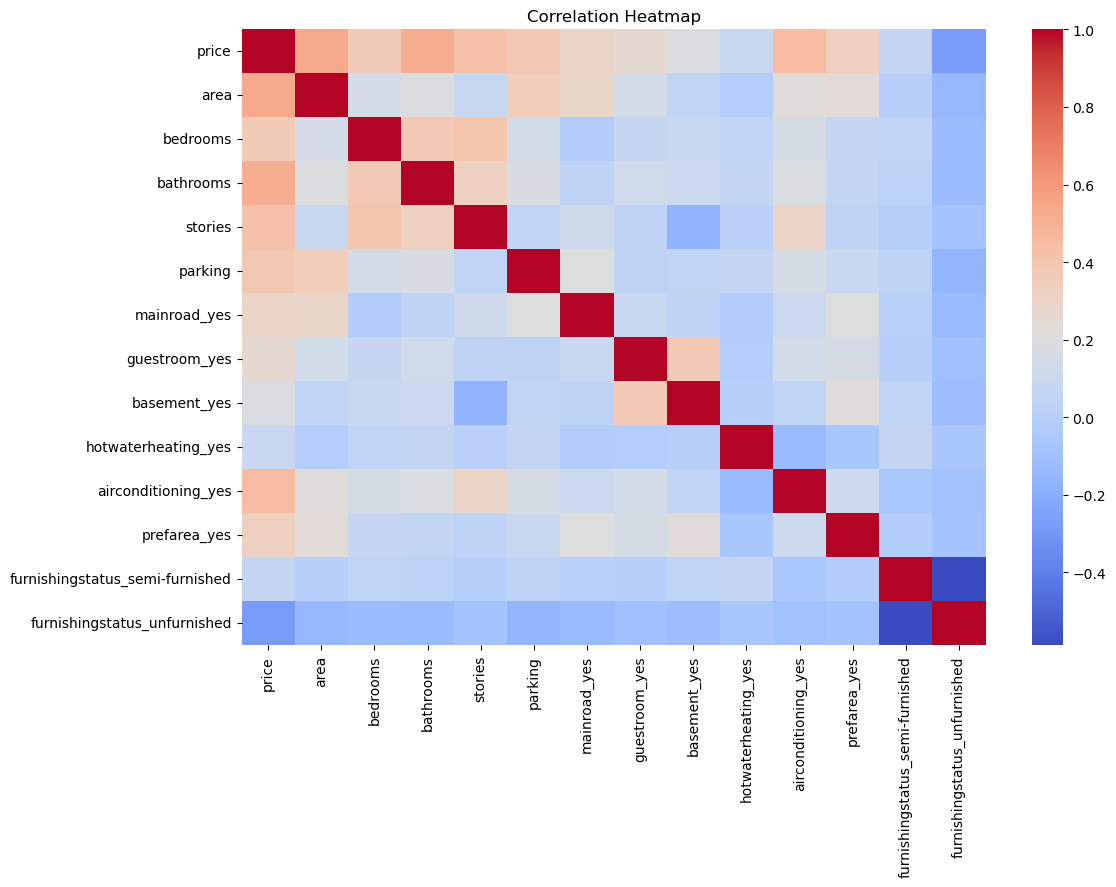

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

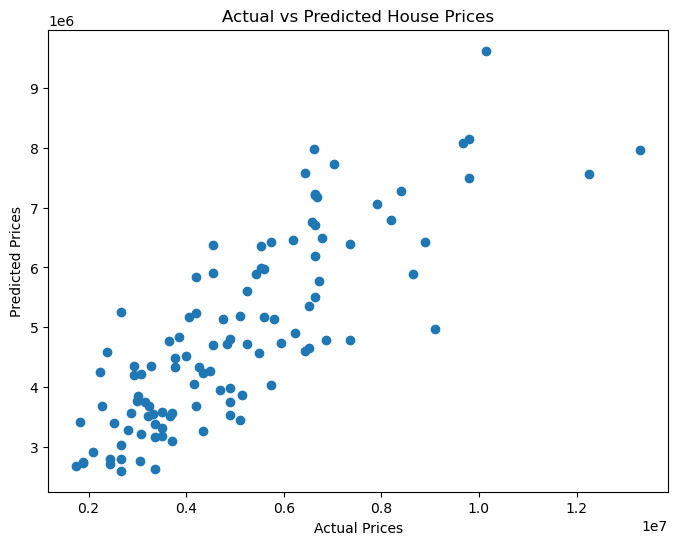

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

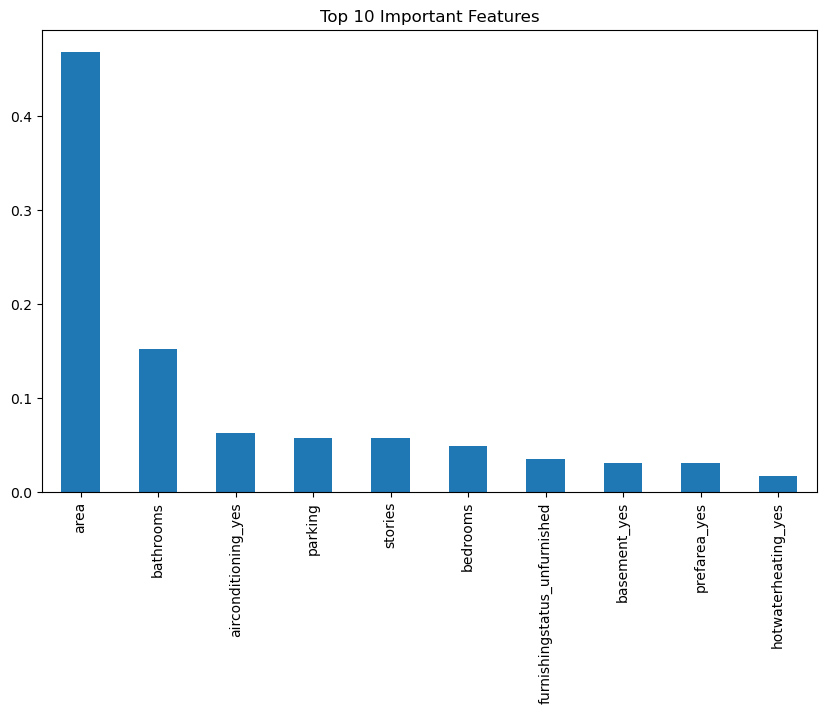

In [15]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top 10 Important Features")
plt.show()

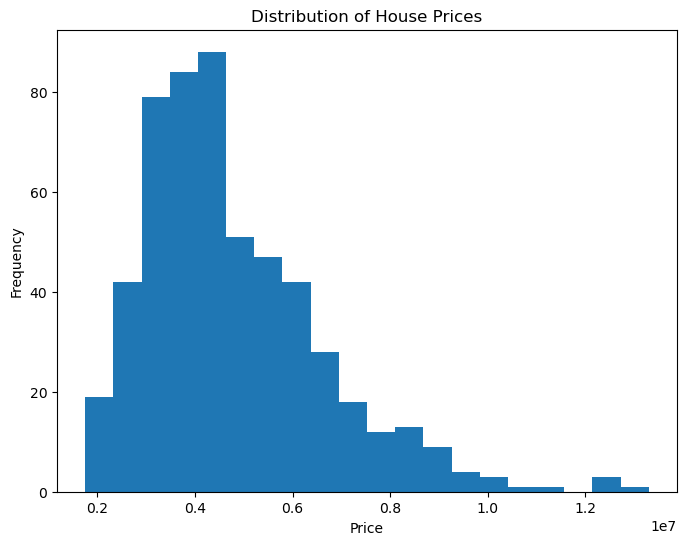

In [16]:
plt.figure(figsize=(8,6))
plt.hist(df["price"], bins=20)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

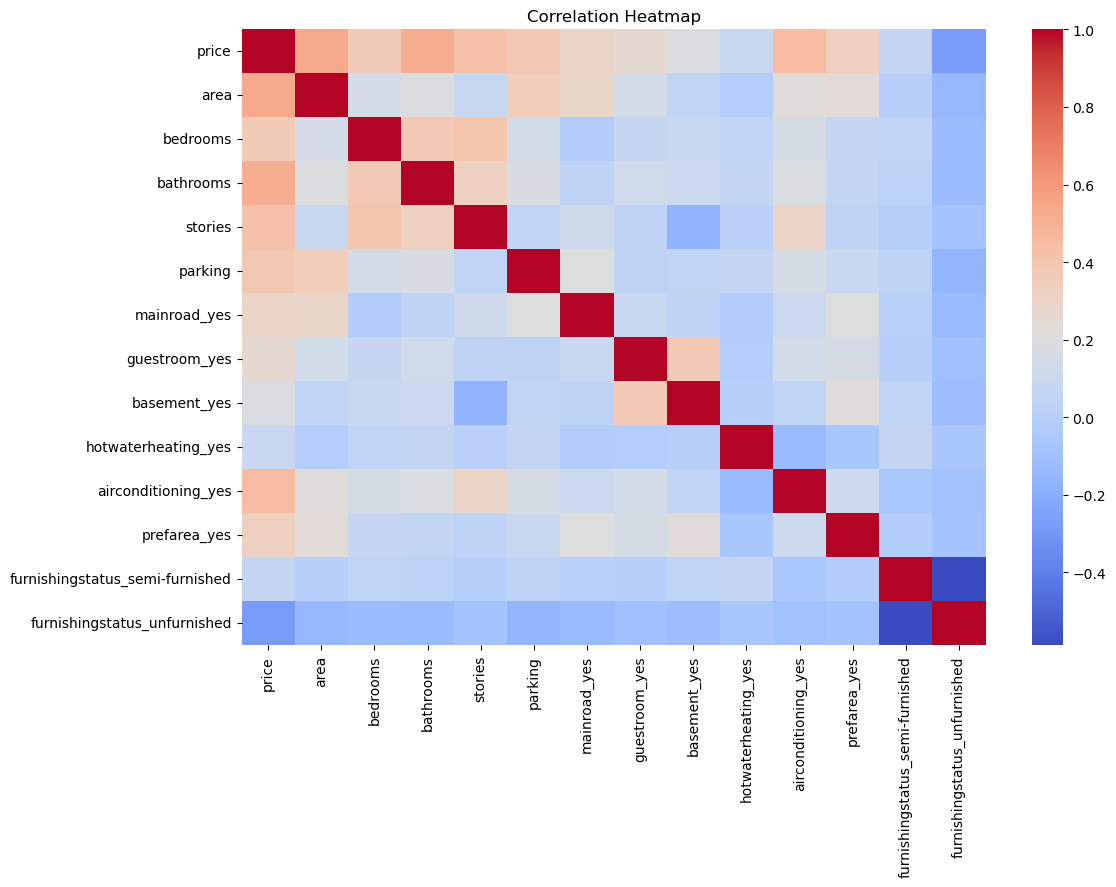

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

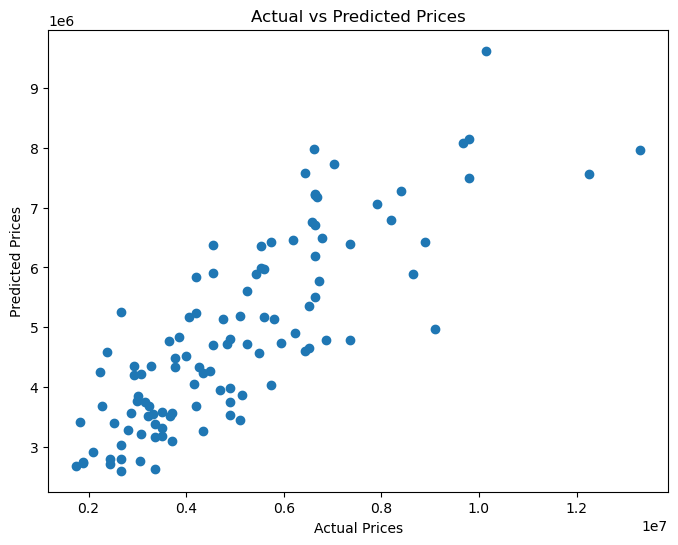

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

In [19]:
import os

print(os.listdir("charts"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'charts'

In [20]:
import os

os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully!")

Charts folder created successfully!


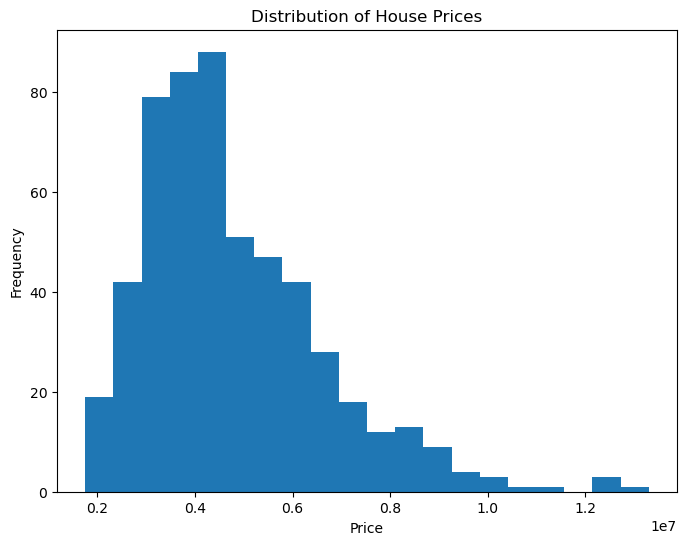

In [21]:
plt.figure(figsize=(8,6))
plt.hist(df["price"], bins=20)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/house_price_distribution.png")
plt.show()

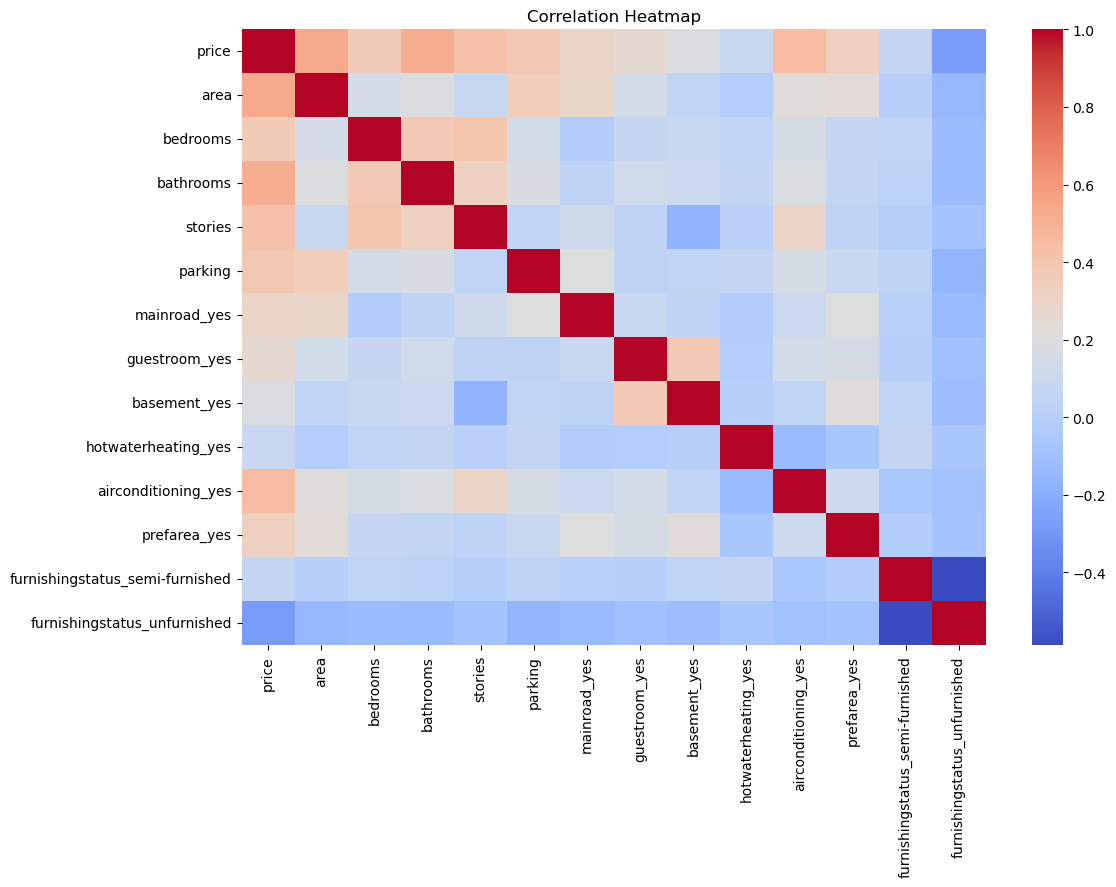

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")
plt.show()

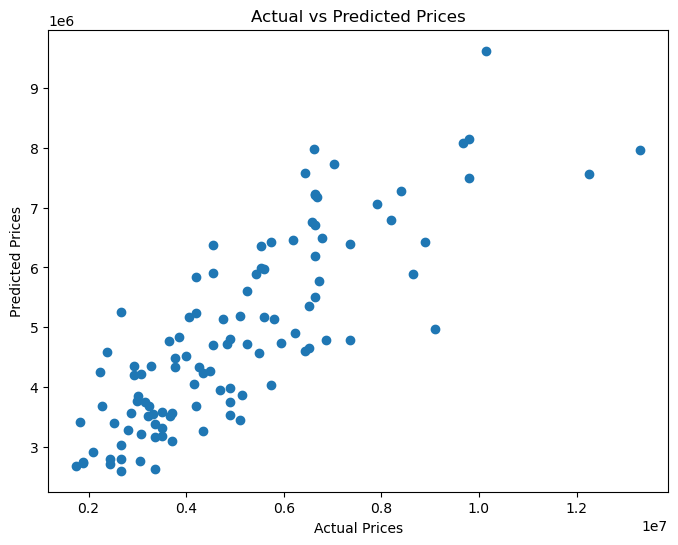

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.savefig("charts/actual_vs_predicted.png")
plt.show()

In [24]:
import os

print(os.listdir("charts"))

['actual_vs_predicted.png', 'correlation_heatmap.png', 'house_price_distribution.png']


In [25]:
print("""
PROJECT INSIGHTS

1. Features Influencing House Price:
   Area, bathrooms, stories, air conditioning, and preferred area
   show strong influence on house prices.

2. Model Accuracy:
   Linear Regression achieved an R² score of 0.653,
   while Random Forest achieved an R² score of 0.612.

3. Interesting Observation:
   Although Random Forest is generally a powerful algorithm,
   Linear Regression performed slightly better on this dataset.

4. Business Recommendation:
   Real-estate businesses should focus on larger houses,
   better amenities, and premium locations when estimating
   property value and planning investments.
""")


PROJECT INSIGHTS

1. Features Influencing House Price:
   Area, bathrooms, stories, air conditioning, and preferred area
   show strong influence on house prices.

2. Model Accuracy:
   Linear Regression achieved an R² score of 0.653,
   while Random Forest achieved an R² score of 0.612.

3. Interesting Observation:
   Although Random Forest is generally a powerful algorithm,
   Linear Regression performed slightly better on this dataset.

4. Business Recommendation:
   Real-estate businesses should focus on larger houses,
   better amenities, and premium locations when estimating
   property value and planning investments.

